# Cella 1 - Importazioni:

In [65]:
# Importazioni
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
import sys

# Configurazione pandas per mostrare tutte le colonne
pd.set_option('display.max_columns', None)  # Mostra tutte le colonne
pd.set_option('display.width', None)        # Nessun limite larghezza
pd.set_option('display.max_colwidth', None) # Mostra testo completo

# Configurazione grafici
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
%matplotlib inline

# Cella 2 - Connessione e caricamento dati:

In [66]:
# Esecuzione notebook pulizia con nbconvert
result_clean = subprocess.run([
    sys.executable, '-m', 'nbconvert', 
    '--to', 'notebook', 
    '--execute', 
    '--ExecutePreprocessor.timeout=600',
    '../notebook/pulizia.ipynb'
], capture_output=True, text=True, cwd='.')

print(result_clean.stdout)
if result_clean.stderr:
    print("STDERR:", result_clean.stderr)


STDERR: [NbConvertApp] Converting notebook ../notebook/pulizia.ipynb to notebook
c:\Users\Utente\OneDrive - ITS Tech Talent Factory\Project Work\Project-Work\venv\lib\site-packages\zmq\_future.py:718: RuntimeWarning: Proactor event loop does not implement add_reader family of methods required for zmq. Registering an additional selector thread for add_reader support via tornado. Use `asyncio.set_event_loop_policy(WindowsSelectorEventLoopPolicy())` to avoid this warning.
  self._get_loop()
[NbConvertApp] Writing 196350 bytes to ..\notebook\pulizia.nbconvert.ipynb



In [67]:
# Connessione al database
# Importa la funzione
import sys
sys.path.append('..')
from script.connessioni import get_mysql_connection

# Usa la connessione
conn = get_mysql_connection()
cursore = conn.cursor()

print("Connesso al database!")

# Legge tutti i dati da clean_data
query = "SELECT * FROM clean_data"
df = pd.read_sql(query, conn)

conn.close()

print(f" Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")
print("\n Prime 5 righe:")
df.head()

Connesso al database!
 Dataset caricato: 282 righe, 37 colonne

 Prime 5 righe:


C:\Users\Utente\AppData\Local\Temp\ipykernel_11624\2743863240.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,email,contesto,età,genere,area_geo,anni_esperienza,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12,Item_13,Item_14,Item_15,Item_16,Item_17,Item_18,Item_19,Item_20,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29,Item_30
0,1,None,Entrambi,24,Femmina,Nord Italia,5.0,4,5,4,4,4,4.0,4.0,5.0,5.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5,5,1,1,2,2,4,5,5,Durante gli esami e se devo interagire con gli insegnanti e i colleghi
1,2,None,Entrambi,24,Femmina,Nord Italia,5.0,4,5,4,4,4,4.0,4.0,5.0,5.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5,5,1,1,2,2,4,5,5,Durante gli esami e se devo interagire con gli insegnanti e i colleghi
2,3,None,Studio,26,Femmina,Nord Italia,7.0,4,5,3,4,3,4.0,3.0,2.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0,NaN,NaN,NaN,NaN,NaN,4,1,3,3,5,2,2,2,4,Durante gli esami
3,4,None,Studio,26,Femmina,Nord Italia,7.0,4,5,3,4,3,4.0,3.0,2.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0,NaN,NaN,NaN,NaN,NaN,4,1,3,3,5,2,2,2,4,Durante gli esami
4,5,None,Lavoro,26,Maschio,Nord Italia,5.0,3,4,3,4,4,4.0,5.0,3.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,4.0,2.0,4.0,5.0,5.0,3,5,1,1,4,2,5,4,5,Interazione con persone (clienti)


# Cella 3 - Info generale sul dataset:

In [68]:
# Informazioni generali
print("Informazioni sul dataset:\n")
df.info()

print("\n Statistiche descrittive:")
df.describe()

Informazioni sul dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282 entries, 0 to 281
Data columns (total 37 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               282 non-null    int64  
 1   email            12 non-null     object 
 2   contesto         282 non-null    object 
 3   età              282 non-null    int64  
 4   genere           282 non-null    object 
 5   area_geo         282 non-null    object 
 6   anni_esperienza  282 non-null    float64
 7   Item_1           282 non-null    int64  
 8   Item_2           282 non-null    int64  
 9   Item_3           282 non-null    int64  
 10  Item_4           282 non-null    int64  
 11  Item_5           282 non-null    int64  
 12  Item_6           276 non-null    float64
 13  Item_7           276 non-null    float64
 14  Item_8           276 non-null    float64
 15  Item_9           278 non-null    float64
 16  Item_10          274 non-null    fl

,id,età,anni_esperienza,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12,Item_13,Item_14,Item_15,Item_16,Item_17,Item_18,Item_19,Item_20,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29
count,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,276.000000,276.000000,276.000000,278.000000,274.000000,176.000000,176.000000,174.000000,172.000000,172.000000,155.000000,155.000000,155.000000,155.000000,155.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000
mean,142.549645,23.769504,4.968298,3.372340,3.638298,2.886525,3.489362,3.687943,3.307971,2.844203,2.576087,2.917266,2.069343,3.392045,3.375000,3.367816,2.936047,2.366279,3.000000,2.954839,3.180645,3.283871,3.109677,2.737589,3.007092,2.890071,2.539007,3.361702,3.265957,2.822695,2.485816,3.975177
std,83.211898,3.463083,4.491965,1.093338,1.139873,1.157320,1.254838,1.184928,1.154946,1.215507,1.199094,1.344996,1.350190,1.242000,1.129475,1.108193,1.170536,1.242344,1.200649,1.260498,1.164803,1.247100,1.219792,1.208778,1.381095,1.063119,1.080515,1.269834,1.197645,1.269874,1.334517,1.075158
min,1.000000,19.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,71.250000,21.000000,1.042500,3.000000,3.000000,2.000000,3.000000,3.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,3.000000,3.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000
50%,141.500000,24.000000,4.000000,3.000000,4.000000,3.000000,4.000000,4.000000,3.000000,3.000000,2.000000,3.000000,1.000000,4.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000,2.000000,4.000000
75%,211.750000,26.000000,7.050000,4.000000,5.000000,4.000000,5.000000,5.000000,4.000000,4.000000,3.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,3.000000,5.000000
max,294.000000,30.000000,24.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


# Cella 4 - Distribuzione età:

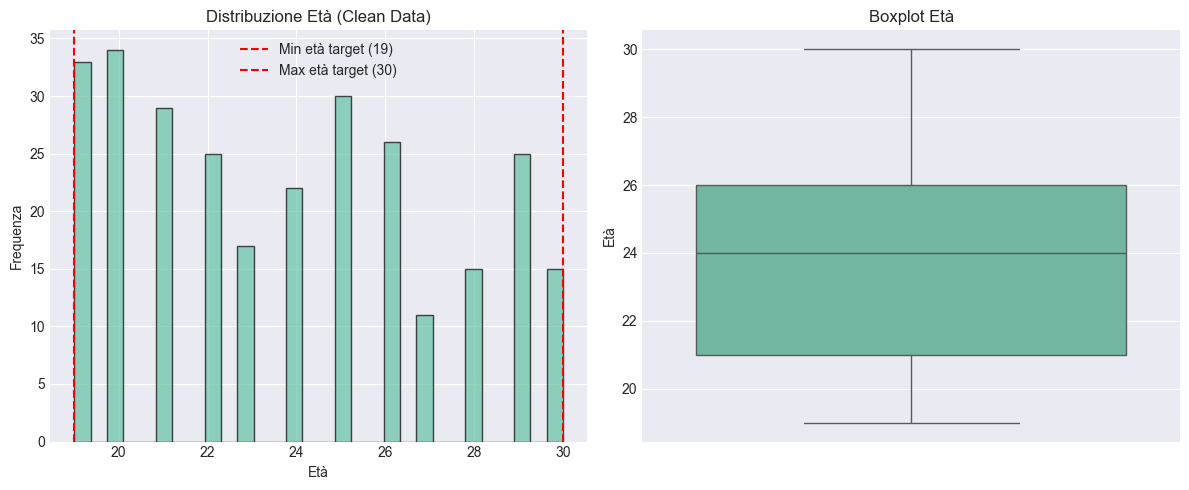

📈 Statistiche età:
   - Min: 19
   - Max: 30
   - Media: 23.77
   - Mediana: 24.0

Righe fuori range (< 19 o > 30): 0


In [69]:
# Distribuzione età
plt.figure(figsize=(12, 5))

# Subplot 1: Istogramma
plt.subplot(1, 2, 1)
df['età'].dropna().astype(str).str.extract('(\d+)')[0].astype(int).hist(bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Età')
plt.ylabel('Frequenza')
plt.title('Distribuzione Età (Clean Data)')
plt.axvline(19, color='red', linestyle='--', label='Min età target (19)') 
plt.axvline(30, color='red', linestyle='--', label='Max età target (30)')
plt.legend()

# Subplot 2: Boxplot
plt.subplot(1, 2, 2)
età_clean = df['età'].dropna().astype(str).str.extract('(\d+)')[0].astype(int)
sns.boxplot(y=età_clean)
plt.ylabel('Età')
plt.title('Boxplot Età')

plt.tight_layout()
plt.show()

# Statistiche età
print(f"📈 Statistiche età:")
print(f"   - Min: {età_clean.min()}")
print(f"   - Max: {età_clean.max()}")
print(f"   - Media: {età_clean.mean():.2f}")
print(f"   - Mediana: {età_clean.median()}")
print(f"\nRighe fuori range (< 19 o > 30): {((età_clean < 19) | (età_clean > 30)).sum()}")  

# Cella 5 - Distribuzione genere:

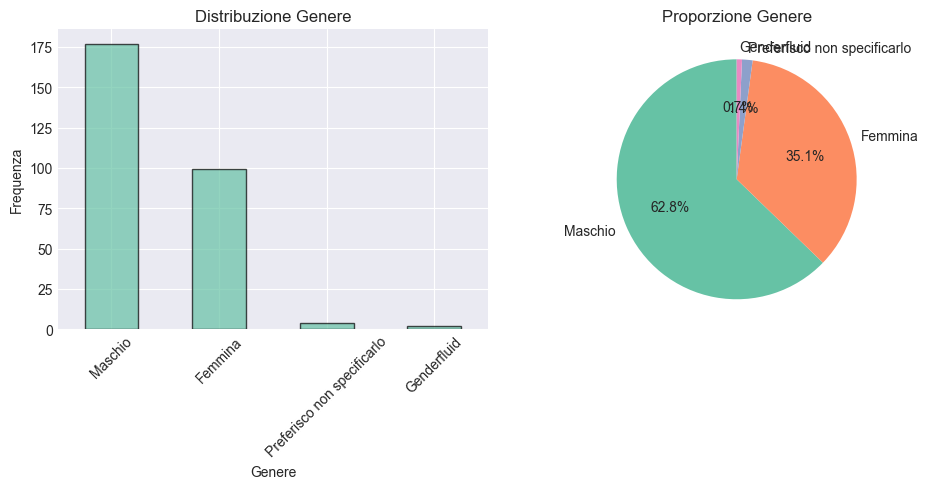


Conteggio per genere:
genere
Maschio                        177
Femmina                         99
Preferisco non specificarlo      4
Genderfluid                      2
Name: count, dtype: int64


In [70]:
# Distribuzione genere
plt.figure(figsize=(10, 5))

# Subplot 1: Barplot
plt.subplot(1, 2, 1)
df['genere'].value_counts().plot(kind='bar', edgecolor='black', alpha=0.7)
plt.xlabel('Genere')
plt.ylabel('Frequenza')
plt.title('Distribuzione Genere')
plt.xticks(rotation=45)

# Subplot 2: Pie chart
plt.subplot(1, 2, 2)
df['genere'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.ylabel('')
plt.title('Proporzione Genere')

plt.tight_layout()
plt.show()

print("\nConteggio per genere:")
print(df['genere'].value_counts())

# Cella 6 - Distribuzione contesto:

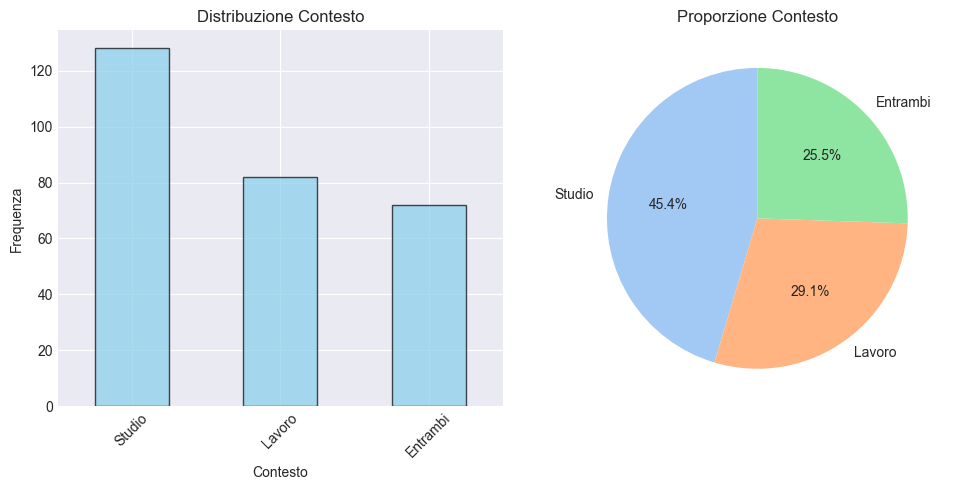


Conteggio per contesto:
contesto
Studio      128
Lavoro       82
Entrambi     72
Name: count, dtype: int64


In [71]:
# Distribuzione contesto (studio/lavoro/entrambi)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
df['contesto'].value_counts().plot(kind='bar', edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Contesto')
plt.ylabel('Frequenza')
plt.title('Distribuzione Contesto')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
df['contesto'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.ylabel('')
plt.title('Proporzione Contesto')

plt.tight_layout()
plt.show()

print("\nConteggio per contesto:")
print(df['contesto'].value_counts())

# Cella 7 - Distribuzione area geografica:

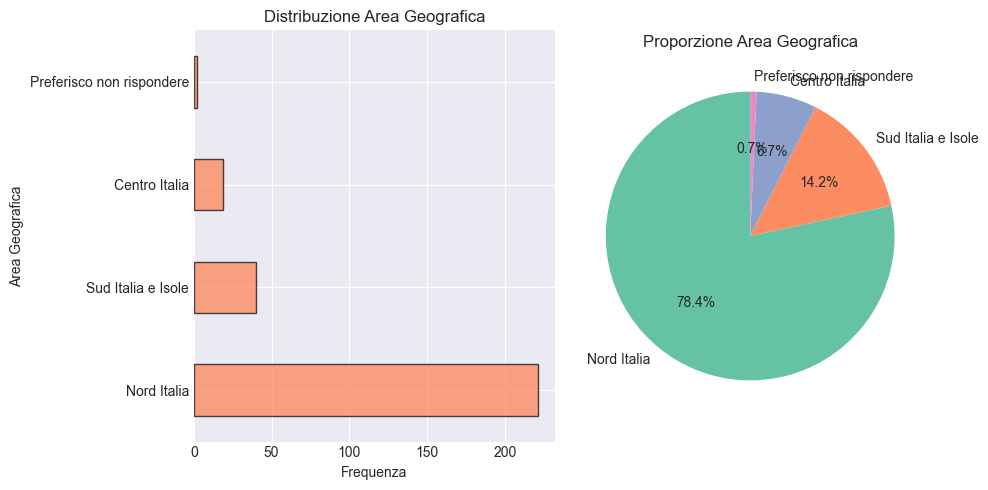


Conteggio per area geografica:
area_geo
Nord Italia                  221
Sud Italia e Isole            40
Centro Italia                 19
Preferisco non rispondere      2
Name: count, dtype: int64


In [72]:
# Distribuzione area geografica
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
df['area_geo'].value_counts().plot(kind='barh', edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Frequenza')
plt.ylabel('Area Geografica')
plt.title('Distribuzione Area Geografica')

plt.subplot(1, 2, 2)
df['area_geo'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.ylabel('')
plt.title('Proporzione Area Geografica')

plt.tight_layout()
plt.show()

print("\nConteggio per area geografica:")
print(df['area_geo'].value_counts())

# Cella 8 - Distribuzione Items (scala Likert):

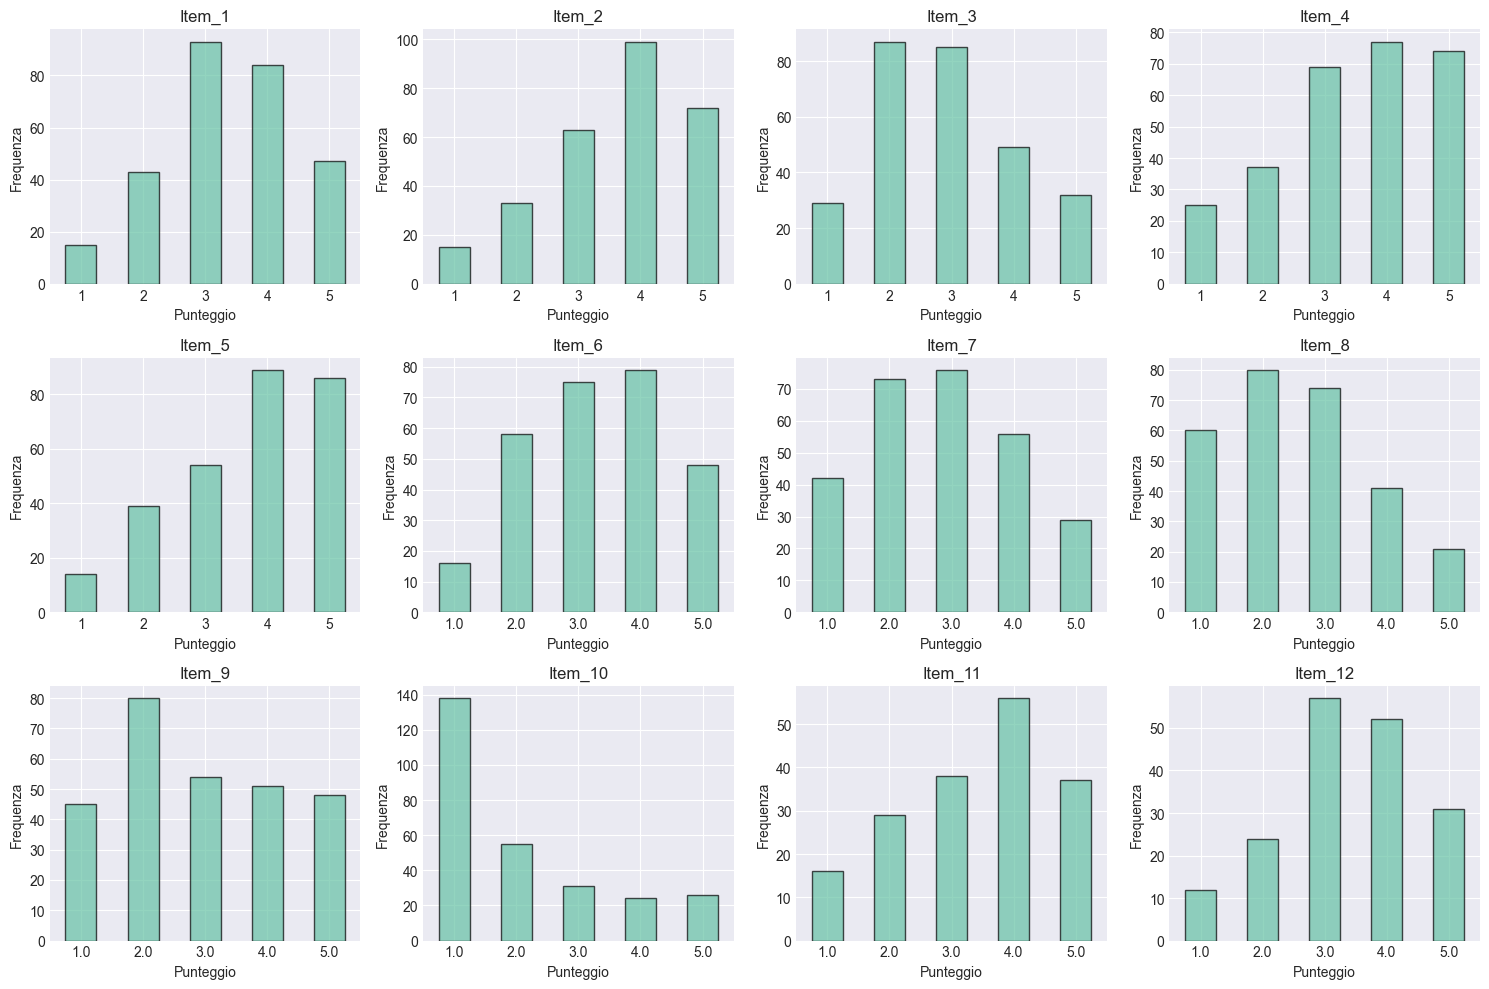


Statistiche Item (scala 1-5):
           Item_1      Item_2      Item_3      Item_4      Item_5      Item_6  \
count  282.000000  282.000000  282.000000  282.000000  282.000000  276.000000   
mean     3.372340    3.638298    2.886525    3.489362    3.687943    3.307971   
std      1.093338    1.139873    1.157320    1.254838    1.184928    1.154946   
min      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   
25%      3.000000    3.000000    2.000000    3.000000    3.000000    2.000000   
50%      3.000000    4.000000    3.000000    4.000000    4.000000    3.000000   
75%      4.000000    5.000000    4.000000    5.000000    5.000000    4.000000   
max      5.000000    5.000000    5.000000    5.000000    5.000000    5.000000   

           Item_7      Item_8      Item_9     Item_10     Item_11     Item_12  \
count  276.000000  276.000000  278.000000  274.000000  176.000000  176.000000   
mean     2.844203    2.576087    2.917266    2.069343    3.392045    3.375000

In [73]:
# Distribuzione delle risposte agli Item (Item_1 a Item_29)
item_cols = [col for col in df.columns if col.startswith('Item_') and col != 'Item_30']

plt.figure(figsize=(15, 10))

for i, col in enumerate(item_cols[:12], 1):
    plt.subplot(3, 4, i)
    df[col].value_counts().sort_index().plot(kind='bar', edgecolor='black', alpha=0.7)
    plt.xlabel('Punteggio')
    plt.ylabel('Frequenza')
    plt.title(f'{col}')
    plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Statistiche degli Item
print("\nStatistiche Item (scala 1-5):")
print(df[item_cols].describe())

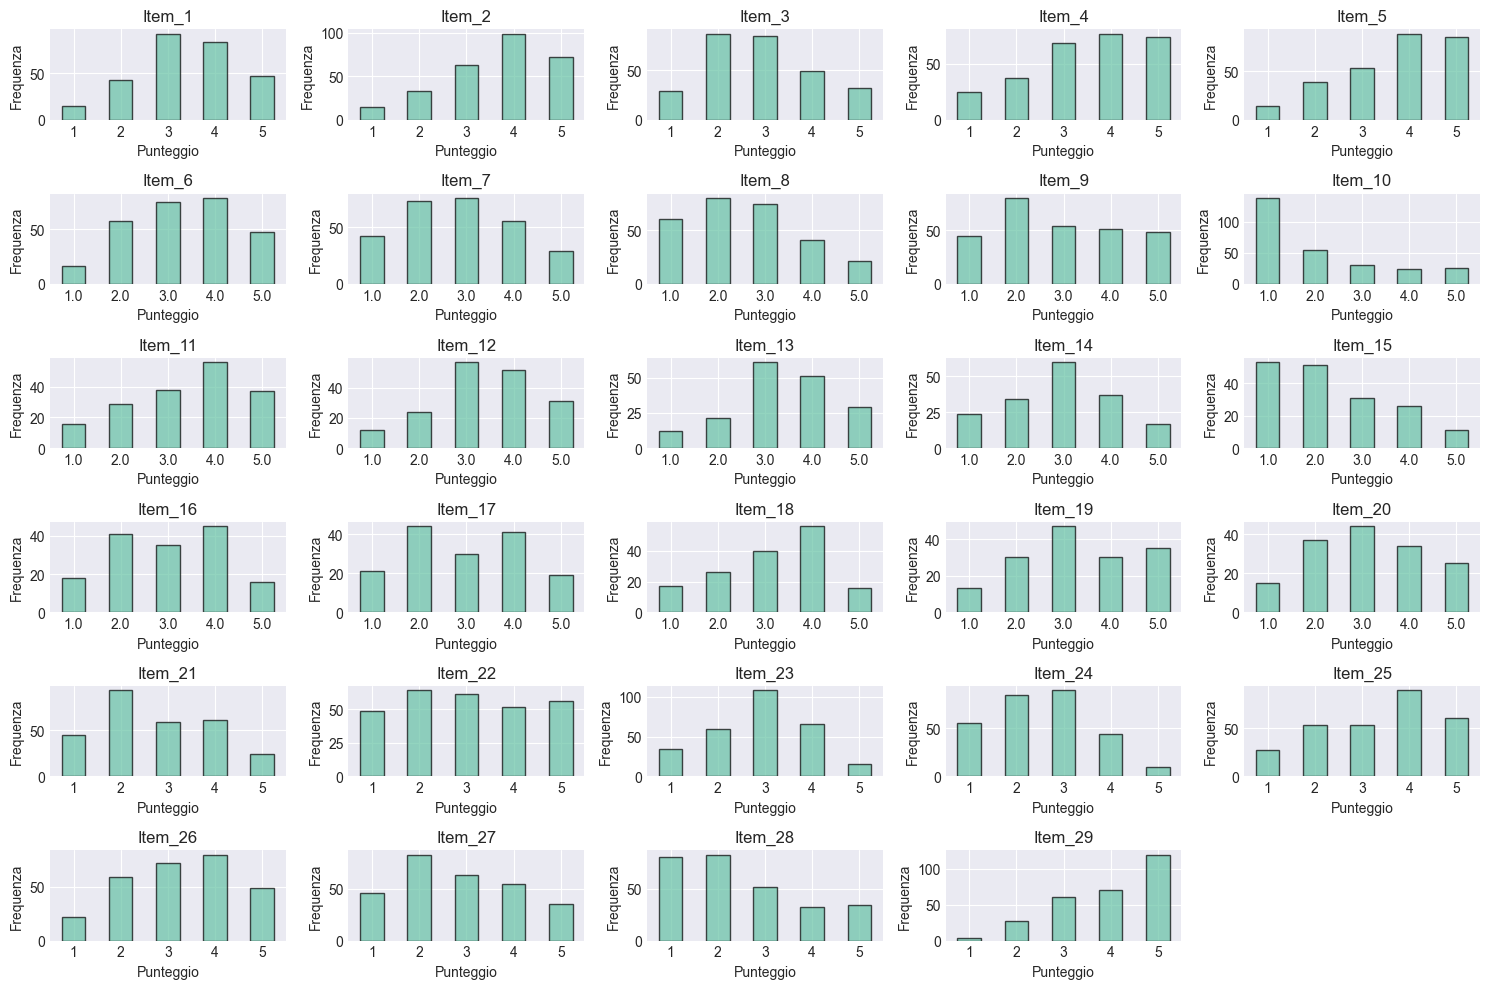


Statistiche Item (scala 1-5):
           Item_1      Item_2      Item_3      Item_4      Item_5      Item_6  \
count  282.000000  282.000000  282.000000  282.000000  282.000000  276.000000   
mean     3.372340    3.638298    2.886525    3.489362    3.687943    3.307971   
std      1.093338    1.139873    1.157320    1.254838    1.184928    1.154946   
min      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   
25%      3.000000    3.000000    2.000000    3.000000    3.000000    2.000000   
50%      3.000000    4.000000    3.000000    4.000000    4.000000    3.000000   
75%      4.000000    5.000000    4.000000    5.000000    5.000000    4.000000   
max      5.000000    5.000000    5.000000    5.000000    5.000000    5.000000   

           Item_7      Item_8      Item_9     Item_10     Item_11     Item_12  \
count  276.000000  276.000000  278.000000  274.000000  176.000000  176.000000   
mean     2.844203    2.576087    2.917266    2.069343    3.392045    3.375000

In [74]:
item_cols = [col for col in df.columns if col.startswith('Item_') and col != 'Item_30']

plt.figure(figsize=(15, 10))

for i, col in enumerate(item_cols[:29], 1):  
    plt.subplot(6, 5, i)
    df[col].value_counts().sort_index().plot(kind='bar', edgecolor='black', alpha=0.7)
    plt.xlabel('Punteggio')
    plt.ylabel('Frequenza')
    plt.title(f'{col}')
    plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Statistiche degli Item
print("\nStatistiche Item (scala 1-5):")
print(df[item_cols].describe())

# Cella 9 - Heatmap correlazioni Items:

Matrice di correlazione (29, 29):


<Figure size 1600x1400 with 0 Axes>

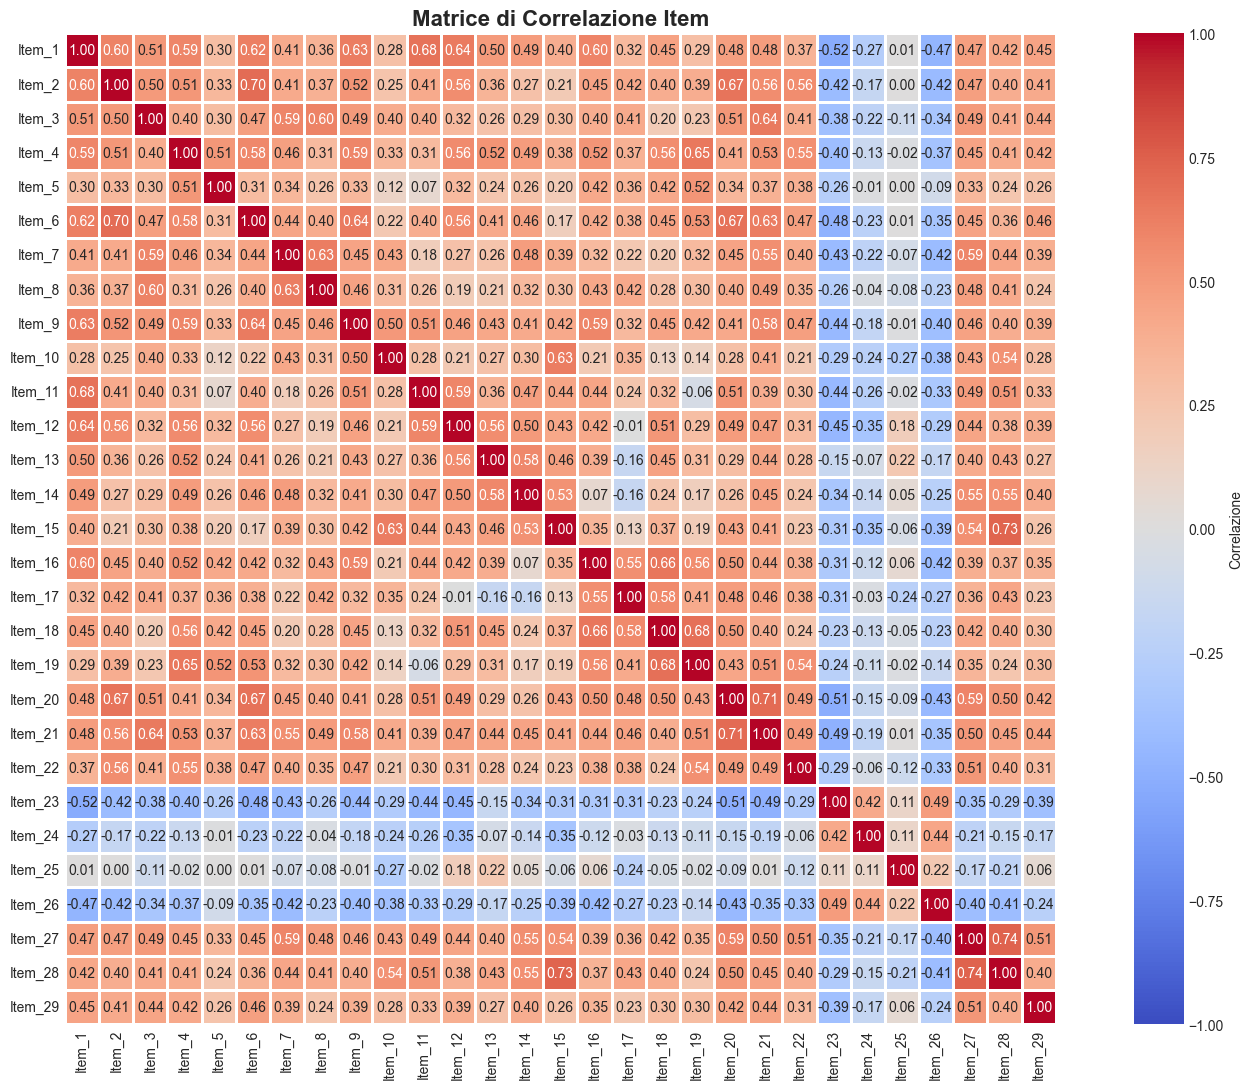


Correlazioni più forti (> 0.7):
Item_28  Item_27    0.739793
Item_27  Item_28    0.739793
Item_28  Item_15    0.731694
Item_15  Item_28    0.731694
Item_20  Item_21    0.705112
Item_21  Item_20    0.705112
dtype: float64


In [75]:
# Heatmap delle correlazioni tra Item
plt.figure(figsize=(16, 14))

corr_matrix = df[item_cols].corr(method='pearson')

print(f"Matrice di correlazione {corr_matrix.shape}:")
plt.figure(figsize=(16, 11))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1, cbar_kws={'label': 'Correlazione'},
            vmin=-1, vmax=1)
plt.title('Matrice di Correlazione Item', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlazioni più alte
print("\nCorrelazioni più forti (> 0.7):")
#mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
#corr_flat = corr_matrix.mask(mask).stack()
#print(corr_flat[corr_flat > 0.7].sort_values(ascending=False).head(10))
print(corr_matrix[(corr_matrix > 0.7) & (corr_matrix != 1)].stack().sort_values(ascending=False).head(10))

# NOTA: cercare mask e stack

# Cella 10 - Valori mancanti:

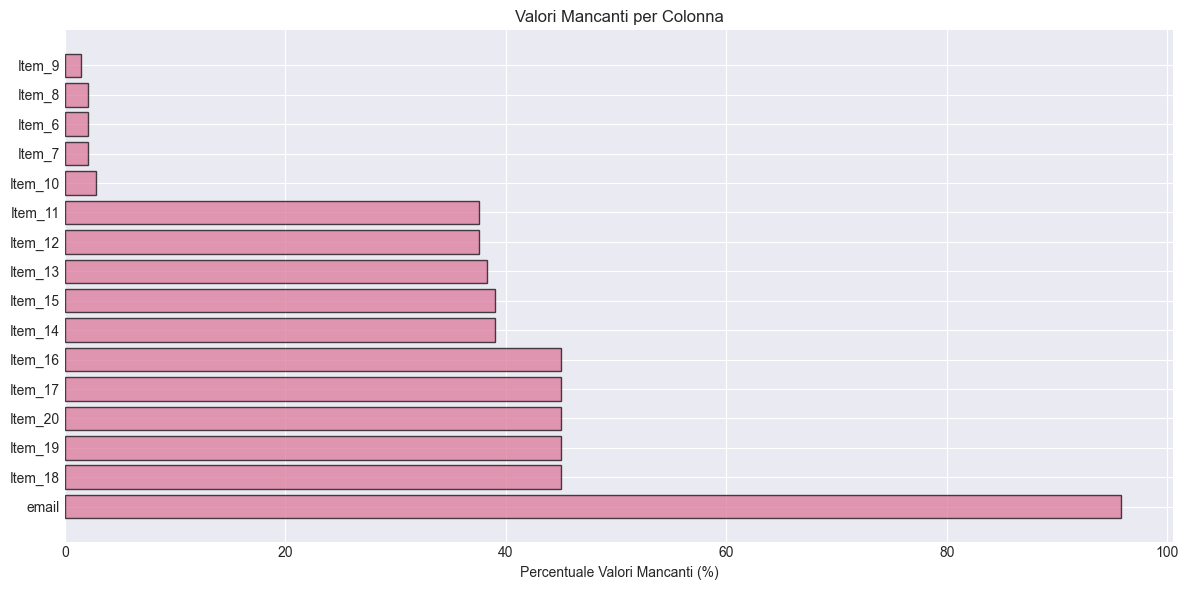


Colonne con valori mancanti:
    Colonna  Valori Mancanti  Percentuale
1     email              270    95.744681
24  Item_18              127    45.035461
25  Item_19              127    45.035461
26  Item_20              127    45.035461
23  Item_17              127    45.035461
22  Item_16              127    45.035461
20  Item_14              110    39.007092
21  Item_15              110    39.007092
19  Item_13              108    38.297872
18  Item_12              106    37.588652
17  Item_11              106    37.588652
16  Item_10                8     2.836879
13   Item_7                6     2.127660
12   Item_6                6     2.127660
14   Item_8                6     2.127660
15   Item_9                4     1.418440


In [76]:
# Analisi valori mancanti
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Colonna': missing.index,
    'Valori Mancanti': missing.values,
    'Percentuale': missing_pct.values
})

missing_df = missing_df[missing_df['Valori Mancanti'] > 0].sort_values('Valori Mancanti', ascending=False)

if len(missing_df) > 0:
    plt.figure(figsize=(12, 6))
    plt.barh(missing_df['Colonna'], missing_df['Percentuale'], edgecolor='black', alpha=0.7, color='palevioletred')
    plt.xlabel('Percentuale Valori Mancanti (%)')
    plt.title('Valori Mancanti per Colonna')
    plt.tight_layout()
    plt.show()
    
    print("\nColonne con valori mancanti:")
    print(missing_df)
else:
    print("\nNessun valore mancante nel dataset!")

# Cella 11 - Summary report (correzione):

In [77]:
# Summary finale
print("SUMMARY ANALISI ESPLORATIVA - CLEAN DATA")
print(f"\nTotale risposte: {len(df)}")
print(f"\nEtà:")
print(f"   - Range: {età_clean.min()} - {età_clean.max()}")
print(f"   - Media: {età_clean.mean():.1f} anni")
print(f"\nGenere:")
print(df['genere'].value_counts())
print(f"\nContesto:")
print(df['contesto'].value_counts())
print(f"\nArea Geografica:")
print(df['area_geo'].value_counts())
print("\n" + "=" * 60)

SUMMARY ANALISI ESPLORATIVA - CLEAN DATA

Totale risposte: 282

Età:
   - Range: 19 - 30
   - Media: 23.8 anni

Genere:
genere
Maschio                        177
Femmina                         99
Preferisco non specificarlo      4
Genderfluid                      2
Name: count, dtype: int64

Contesto:
contesto
Studio      128
Lavoro       82
Entrambi     72
Name: count, dtype: int64

Area Geografica:
area_geo
Nord Italia                  221
Sud Italia e Isole            40
Centro Italia                 19
Preferisco non rispondere      2
Name: count, dtype: int64



In [78]:
import os
import json
from datetime import datetime

# Crea directory di output
output_dir = '../output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Prepara i dati
statistics = pd.DataFrame({
    'Metrica': ['Totale risposte', 'Età minima', 'Età massima', 'Età media', 'Età mediana'],
    'Valore': [len(df), età_clean.min(), età_clean.max(), f"{età_clean.mean():.2f}", f"{età_clean.median():.0f}"]
})

genere_dist = df['genere'].value_counts().reset_index()
genere_dist.columns = ['Genere', 'Frequenza']

contesto_dist = df['contesto'].value_counts().reset_index()
contesto_dist.columns = ['Contesto', 'Frequenza']

area_dist = df['area_geo'].value_counts().reset_index()
area_dist.columns = ['Area', 'Frequenza']

# Esporta in Excel
excel_path = os.path.join(output_dir, f'analisi_esplorativa_{timestamp}.xlsx')
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    statistics.to_excel(writer, sheet_name='Statistiche', index=False)
    genere_dist.to_excel(writer, sheet_name='Genere', index=False)
    contesto_dist.to_excel(writer, sheet_name='Contesto', index=False)
    area_dist.to_excel(writer, sheet_name='Area Geografica', index=False)
    if not missing_df.empty:
        missing_df.to_excel(writer, sheet_name='Valori Mancanti', index=False)
    corr_matrix.to_excel(writer, sheet_name='Correlazioni')

# Esporta in JSON 
rag_data = {
    "metadata": {
        "timestamp": timestamp,
        "source": "analisi_esplorativa_post",
        "total_responses": len(df),
        "version": "1.0",
        "language": "it"
    },
    "sections": {
        "statistiche_generali": {
            "descrizione": "Statistiche principali del dataset pulito con informazioni sulla distribuzione dell'età",
            "dati": statistics.to_dict('records')
        },
        "distribuzione_genere": {
            "descrizione": "Distribuzione dei rispondenti per genere. Mostra il numero e la percentuale di risposte per ciascun genere",
            "dati": genere_dist.to_dict('records')
        },
        "distribuzione_contesto": {
            "descrizione": "Distribuzione dei rispondenti per contesto di compilazione (studio, lavoro o entrambi). Indica dove è stato completato il questionario",
            "dati": contesto_dist.to_dict('records')
        },
        "distribuzione_area_geografica": {
            "descrizione": "Distribuzione geografica dei rispondenti per area. Mostra da quali regioni provengono le risposte",
            "dati": area_dist.to_dict('records')
        },
        "valori_mancanti": {
            "descrizione": "Analisi dei valori mancanti nel dataset. Identifica colonne con dati incompleti e la percentuale di incompletezza",
            "dati": missing_df.to_dict('records') if not missing_df.empty else []
        },
        "correlazioni": {
            "descrizione": "Matrice di correlazione di Pearson tra gli item della scala Likert. Valori vicini a 1 indicano forte correlazione positiva",
            "dati": corr_matrix.to_dict('split')
        }
    }
}

json_path = os.path.join('../WEB APP/backend/output_rag', f'analisi_esplorativa_rag_{timestamp}.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(rag_data, f, indent=2, ensure_ascii=False)

print(f"Excel: {excel_path}")
print(f"JSON RAG: {json_path}")

Excel: ../output\analisi_esplorativa_20260423_191945.xlsx
JSON RAG: ../WEB APP/backend/output_rag\analisi_esplorativa_rag_20260423_191945.json
